# Introduction

In this notebook, we delve into the world of time series analysis, an essential component of data analysis in various fields such as finance, economics, and business. Specifically, we will explore the revenue data of a business, understand its trends, seasonality, and other characteristics, and predict future revenue using different time series forecasting models.

The data we are using is a synthetic dataset that mimics the daily revenue figures of a business from 2018 to 2023, adjusted for real-world events and influences, including the COVID-19 pandemic's impact. Our aim is to equip you with the knowledge and skills to prepare and analyze time series data, select appropriate forecasting models, and interpret the results to make informed decisions.


## Setup

In [42]:
# Importing necessary libraries for data manipulation, analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error


Loading and inspecting the data

In [10]:
# Loading the dataset
data = pd.read_csv('revenue.csv', parse_dates=['Date'], index_col='Date')

# Display the first few rows of the dataset, checking for any visible issues like missing values.
data.head()


,Revenue_LKR,Active_Customers
Date,,
2018-01-01,2.131113e+06,8272
2018-01-02,2.016356e+06,7084
2018-01-03,1.794542e+06,4406
2018-01-04,2.137224e+06,9533
2018-01-05,1.986883e+06,9867


In [12]:
# Summary statistics of the dataset
data.describe()

,Revenue_LKR,Active_Customers
count,1.811000e+03,1826.000000
mean,1.880793e+06,6535.032859
std,4.674786e+05,2361.523061
min,5.791769e+05,1229.000000
25%,1.739193e+06,4816.250000
50%,1.963619e+06,6385.500000
75%,2.201291e+06,8261.500000
max,4.564718e+06,21812.000000


In [15]:
#Check for missing values
data.isna().sum()

Revenue_LKR         15
Active_Customers     0
dtype: int64

## Exploratory Data Analysis (EDA)

Before we dive into forecasting models, it's crucial to understand the underlying patterns and characteristics of the time series data. This understanding will inform our choice of models and forecasting strategies.


### Handling Missing Data

After handling missing values:
Revenue_LKR            0
Active_Customers       0
Revenue_Differenced    0
dtype: int64


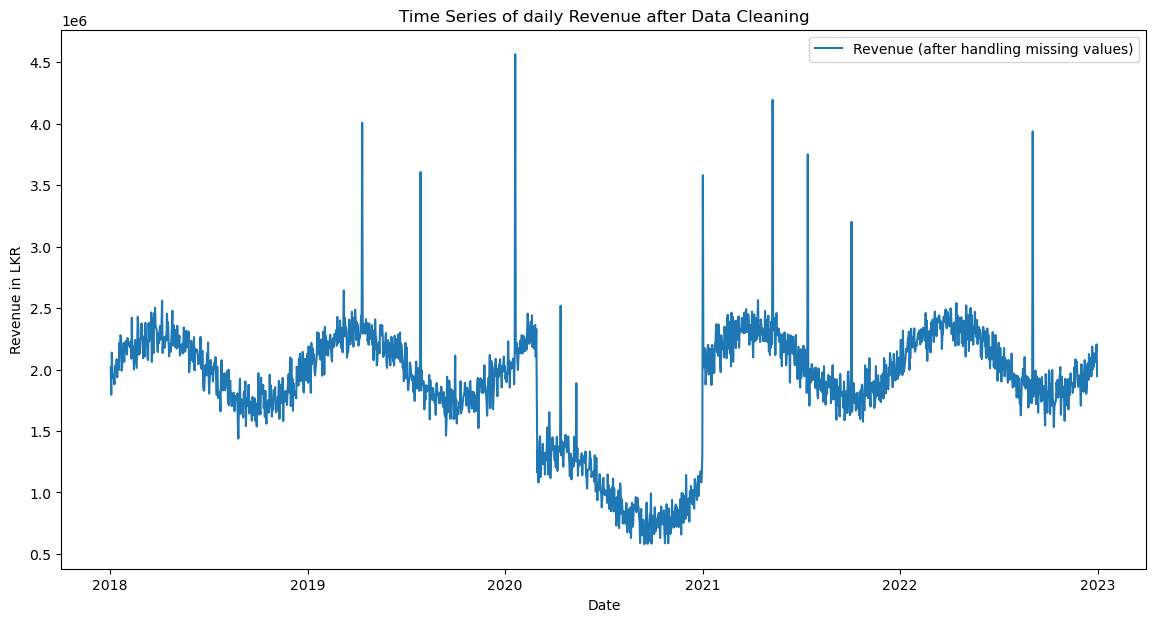

In [34]:
# It's crucial to handle missing data appropriately. We will demonstrate several methods.

# Method 1: Forward fill
data_ffill = data.fillna(method='ffill')

# Method 2: Backward fill
data_bfill = data.fillna(method='bfill')

# Method 3: Interpolation
data_interpolated = data.interpolate(method='time')

# We can choose the best method suited for our time series data. For this notebook, we will use interpolation.
data = data_interpolated

print("After handling missing values:")
print(data.isna().sum())

# Visualizing the time series after missing data handling to check for any inconsistencies.
plt.figure(figsize=(14,7))
plt.plot(data['Revenue_LKR'], label='Revenue (after handling missing values)', linestyle='-')
plt.title('Time Series of daily Revenue after Data Cleaning')
plt.xlabel('Date')
plt.ylabel('Revenue in LKR')
plt.legend()
plt.show()


## Decomposition of Time Series

Decomposition of a time series involves understanding its underlying structure in terms of trend, seasonality, and residuals. This can provide insights into the behavior of the series, and any patterns observed can be leveraged in forecasting.


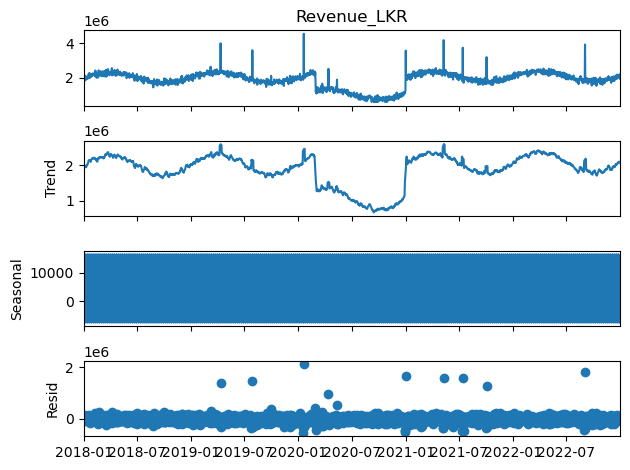

In [18]:
# Seasonal Decomposition of the Time Series
decomposition = seasonal_decompose(data['Revenue_LKR'], model='additive')
decomposition.plot()
plt.show()


### Testing for Stationary

Many time series models require the data to be stationary. A stationary time series is one whose properties do not depend on the time at which the series is observed. We'll use the Dickey-Fuller Test to check for stationarity.


In [19]:
def test_stationarity(timeseries):
    # Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

# Testing for stationarity
test_stationarity(data['Revenue_LKR'])


Results of Dickey-Fuller Test:
Test Statistic                   -2.038830
p-value                           0.269811
#Lags Used                        9.000000
Number of Observations Used    1816.000000
Critical Value (1%)              -3.433956
Critical Value (5%)              -2.863133
Critical Value (10%)             -2.567618
dtype: float64


If the time series is not stationary, we may need to transform it to make it so. Common methods include differencing and transformations like logarithm or square root.


In [20]:
# Let's apply differencing to make the series stationary
data['Revenue_Differenced'] = data['Revenue_LKR'].diff()
data.dropna(inplace=True)  # drop the first row which will be NaN due to differencing

# Test for stationarity on differenced data
test_stationarity(data['Revenue_Differenced'])


Results of Dickey-Fuller Test:
Test Statistic                  -21.561276
p-value                           0.000000
#Lags Used                        8.000000
Number of Observations Used    1816.000000
Critical Value (1%)              -3.433956
Critical Value (5%)              -2.863133
Critical Value (10%)             -2.567618
dtype: float64


With the time series data prepared, we'll now delve into various forecasting models. We'll start with simpler models and gradually explore more complex ones.


## Building Time Series Forecasting Models

With the time series data prepared, we'll now delve into various forecasting models. We'll start with simpler models and gradually explore more complex ones.


In [35]:
# Assuming 'data' contains your time series
train_data = data[:'2022-12-01']  # Adjust the date accordingly
test_data = data['2022-12-01':]  # This holds the true values for the month of December

# The 'train_data' will be used for training the forecasting models.
# The 'test_data' will be used as a benchmark to compare the forecasts.


### Naive Approach

The naive approach assumes that future values will replicate the most recent observations. It serves as a baseline for more complex models.


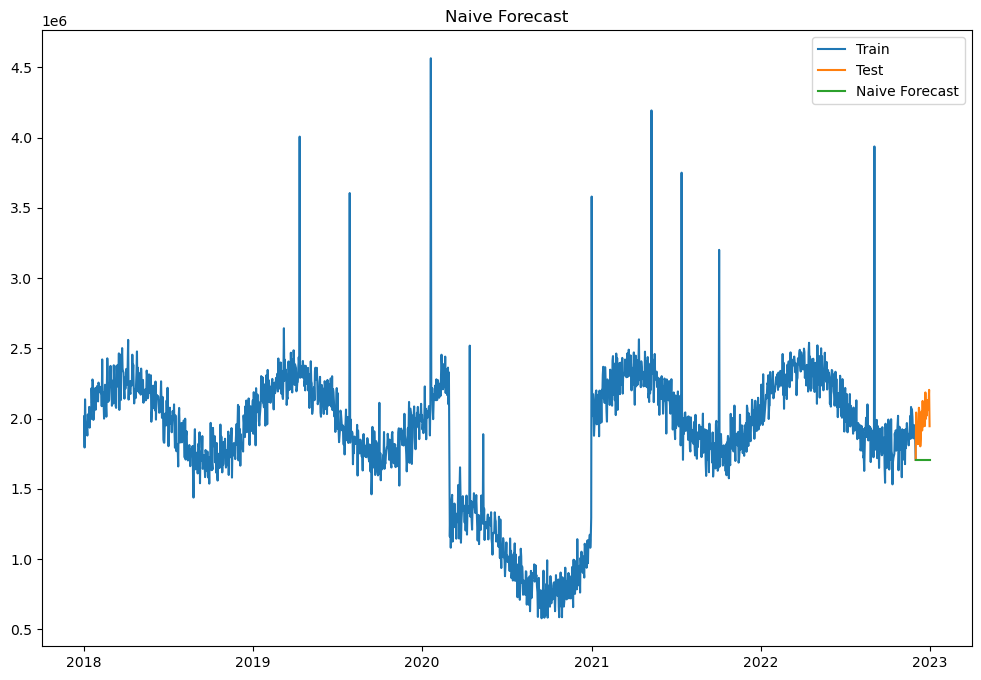

RMSE for Naive Approach: 314413.16697883076
MAE for Naive Approach: 292510.7787305142
MAPE for Naive Approach: 14.339340538840768


In [43]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Placeholder for forecast results
y_hat = test_data.copy()

# Naive Forecast
dd = np.asarray(train_data['Revenue_LKR'])
y_hat['naive'] = dd[len(dd)-1]

# Plotting
plt.figure(figsize=(12,8))
plt.plot(train_data.index, train_data['Revenue_LKR'], label='Train')
plt.plot(test_data.index, test_data['Revenue_LKR'], label='Test')
plt.plot(y_hat.index, y_hat['naive'], label='Naive Forecast')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.show()

# Calculating RMSE to evaluate
rms = sqrt(mean_squared_error(test_data['Revenue_LKR'], y_hat['naive']))
mae = mean_absolute_error(test_data['Revenue_LKR'], y_hat['naive'])
mape = np.mean(np.abs((test_data['Revenue_LKR'] - y_hat['naive']) / test_data['Revenue_LKR'])) * 100

print(f"RMSE for Naive Approach: {rms}")
print(f"MAE for Naive Approach: {mae}")
print(f"MAPE for Naive Approach: {mape}")

### Moving Average

The moving average method involves taking the average of a fixed subset of the time series to smooth short-term fluctuations and highlight long-term trends or cycles.


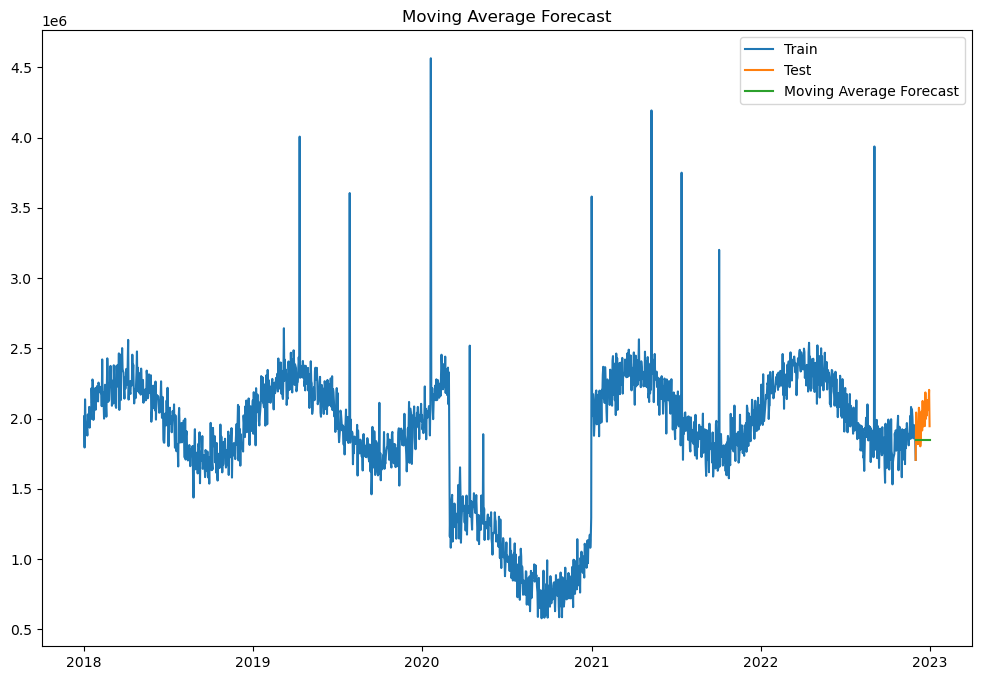

RMSE for Moving Average: 189836.4667331373
MAE for Moving Average: 165494.98857552116
MAPE for Moving Average: 8.067365032985316


In [44]:
# Moving Average
y_hat_avg = test_data.copy()
y_hat_avg['moving_avg_forecast'] = train_data['Revenue_LKR'].rolling(60).mean().iloc[-1]  # average of last 60 observations

plt.figure(figsize=(12,8))
plt.plot(train_data['Revenue_LKR'], label='Train')
plt.plot(test_data['Revenue_LKR'], label='Test')
plt.plot(y_hat_avg['moving_avg_forecast'], label='Moving Average Forecast')
plt.legend(loc='best')
plt.title("Moving Average Forecast")
plt.show()

# Calculating RMSE to evaluate
rms = sqrt(mean_squared_error(test_data['Revenue_LKR'], y_hat_avg['moving_avg_forecast']))
mae = mean_absolute_error(test_data['Revenue_LKR'], y_hat_avg['moving_avg_forecast'])
mape = np.mean(np.abs((test_data['Revenue_LKR'] - y_hat_avg['moving_avg_forecast']) / test_data['Revenue_LKR'])) * 100

print(f"RMSE for Moving Average: {rms}")
print(f"MAE for Moving Average: {mae}")
print(f"MAPE for Moving Average: {mape}")

### Arima

ARIMA (AutoRegressive Integrated Moving Average) is a popular statistical method for time series forecasting that uses historical data points to make predictions.


/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


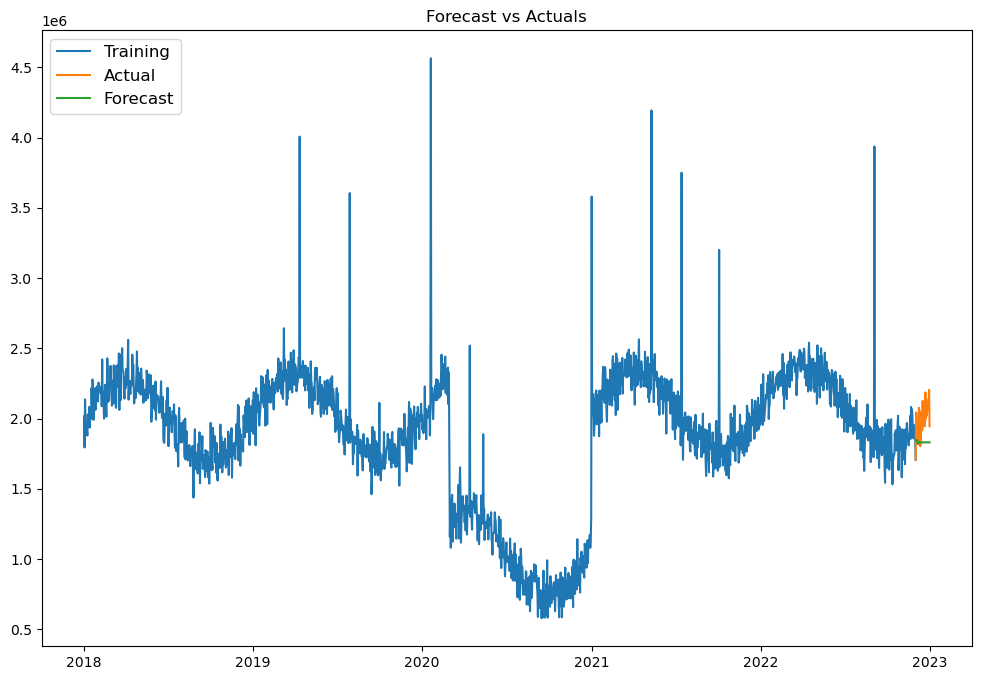

ValueError: Input contains NaN.

In [45]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(train_data['Revenue_LKR'], order=(5,1,0))  # values of p, d, q should be optimized
model_fit = model.fit()

# Forecast
fc, se, conf = model_fit.forecast(30, alpha=0.05)  # 95% confidence interval

# Make as pandas series
fc_series = pd.Series(fc, index=test_data.index)

# Plotting
plt.figure(figsize=(12,8))
plt.plot(train_data['Revenue_LKR'], label='Training')
plt.plot(test_data['Revenue_LKR'], label='Actual')
plt.plot(fc_series, label='Forecast')
plt.fill_between(test_data.index, conf[:, 0], conf[:, 1], color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=12)
plt.show()

# Calculating RMSE to evaluate
rms = sqrt(mean_squared_error(test_data['Revenue_LKR'], fc_series))
mae = mean_absolute_error(test_data['Revenue_LKR'], fc_series)
mape = np.mean(np.abs((test_data['Revenue_LKR'] - fc_series) / test_data['Revenue_LKR'])) * 100

print(f"RMSE for ARIMA: {rms}")
print(f"MAE for ARIMA: {mae}")
print(f"MAPE for ARIMA: {mape}")

### SARIMA

SARIMA, an extension of ARIMA, accounts for seasonality by including seasonal differencing and seasonal autoregressive and moving average terms.


/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/nizar/Documents/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.36340D+01    |proj g|=  6.69023D-02

At iterate    5    f=  1.35857D+01    |proj g|=  1.62329D-02

At iterate   10    f=  1.35841D+01    |proj g|=  3.27027D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     13     16      1     0     0   3.510D-05   1.358D+01
  F =   13.584077473146834     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


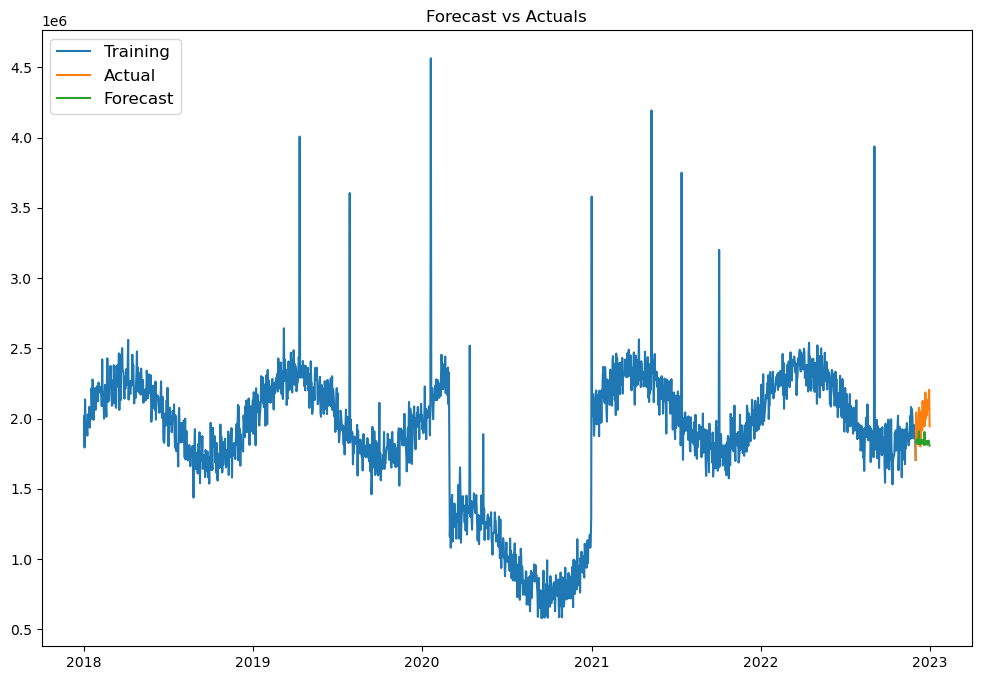

ValueError: Input contains NaN.

In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit a SARIMA model
model = SARIMAX(train_data['Revenue_LKR'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

# Forecasting
fc = model_fit.forecast(steps=30)
fc_series = pd.Series(fc, index=test_data.index)

# Plotting
plt.figure(figsize=(12,8))
plt.plot(train_data['Revenue_LKR'], label='Training')
plt.plot(test_data['Revenue_LKR'], label='Actual')
plt.plot(fc_series, label='Forecast')
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=12)
plt.show()

# Calculating RMSE to evaluate
rms = sqrt(mean_squared_error(test_data['Revenue_LKR'], fc_series))
mae = mean_absolute_error(test_data['Revenue_LKR'], fc_series)
mape = np.mean(np.abs((test_data['Revenue_LKR'] - fc_series) / test_data['Revenue_LKR'])) * 100

print(f"RMSE for SARIMA: {rms}")
print(f"MAE for SARIMA: {mae}")
print(f"MAPE for SARIMA: {mape}")

### Prophet

Prophet, developed by Facebook, is robust to missing data and shifts in the trend, and typically handles outliers well. It works best with time series that have strong seasonal effects and several seasons of historical data.


In [40]:
from fbprophet import Prophet

# Preparing data for Prophet
prophet_data = train_data.reset_index().rename(columns={'Date': 'ds', 'Revenue_LKR': 'y'})

# Fit Prophet model
model = Prophet(yearly_seasonality=True)
model.fit(prophet_data)

# Create future dataframe
future = model.make_future_dataframe(periods=30)  # forecast 30 days

# Forecast
forecast = model.predict(future)
forecast['day'] = forecast['ds'].dt.date

# Plotting
fig1 = model.plot(forecast)

# Extracting the forecasted values for the last 30 days
y_pred = forecast['yhat'][-30:].values
y_true = test_data['Revenue_LKR'].values

# Calculating the metrics
rms = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE for Prophet: {rms}")
print(f"MAE for Prophet: {mae}")
print(f"MAPE for Prophet: {mape}")


ModuleNotFoundError: No module named 'fbprophet'

### Long Short-term Memory (LSTM)

LSTM is a type of recurrent neural network capable of learning order dependence in sequence prediction problems. It is particularly useful for time series forecasting given the temporal behavior of these data sets.


## Model Evaluation

In [46]:
# Placeholder for forecast results and actual values
forecasts = {}
actuals = test_data['Revenue_LKR'].values

# Assuming 'y_hat' is a DataFrame that contains all the forecasted values from different models
# For example, y_hat['naive'], y_hat['arima'], etc., each representing a model's forecasts

models = ['naive', 'moving_avg', 'arima', 'sarima', 'prophet']  # Add other model names as needed

for model in models:
    forecasts[model] = y_hat[model].values  # Extracting forecasted values

# Calculate MAE and MAPE for each model
evaluation_results = {}

for model in models:
    mae = mean_absolute_error(actuals, forecasts[model])
    mape = np.mean(np.abs((actuals - forecasts[model]) / actuals)) * 100
    
    evaluation_results[model] = {'MAE': mae, 'MAPE': mape}

# Display the evaluation results
for model, metrics in evaluation_results.items():
    print(f"Model: {model}")
    print(f"MAE: {metrics['MAE']}")
    print(f"MAPE: {metrics['MAPE']}%")
    print("---")


KeyError: 'moving_avg'